In [1]:
# Import libraries
import numpy as np
import pandas as pd

c:\Users\ASUS\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\ASUS\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (


In [2]:
# Sets the pandas dataframe options to display all columns/ rows.
pd.options.display.max_rows = None

In [3]:
# Load preprocessed data

loan_data_preprocessed_backup = pd.read_pickle('preprocessing_v2.pkl')


In [4]:
# Sanity check
loan_data_preprocessed_backup.shape

(2255821, 244)

In [5]:
# Sanity check
loan_data_preprocessed_backup.head()


,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,grade,sub_grade,emp_title,home_ownership,annual_inc,...,initial_list_status:f,initial_list_status:w,application_type:Individual,application_type:Joint App,hardship_flag:N,hardship_flag:Y,debt_settlement_flag:N,debt_settlement_flag:Y,disbursement_method:Cash,disbursement_method:DirectPay
0,2500,2500,2500.0,13.56,84.92,C,C1,71916,RENT,55000.0,...,0,1,1,0,1,0,1,0,1,0
1,30000,30000,30000.0,18.94,777.23,D,D2,298566,MORTGAGE,90000.0,...,0,1,1,0,1,0,1,0,1,0
2,5000,5000,5000.0,17.97,180.69,D,D1,15034,MORTGAGE,59280.0,...,0,1,1,0,1,0,1,0,1,0
3,4000,4000,4000.0,18.94,146.51,D,D2,194896,MORTGAGE,92000.0,...,0,1,1,0,1,0,1,0,1,0
4,30000,30000,30000.0,16.14,731.78,C,C4,248604,MORTGAGE,57250.0,...,0,1,1,0,1,0,1,0,1,0


In [6]:
# Sanity check

loan_data_preprocessed_backup.columns.values

array(['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'int_rate',
       'installment', 'grade', 'sub_grade', 'emp_title', 'home_ownership',
       'annual_inc', 'verification_status', 'issue_d', 'loan_status',
       'pymnt_plan', 'purpose', 'title', 'addr_state', 'dti',
       'delinq_2yrs', 'inq_last_6mths', 'mths_since_last_delinq',
       'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal',
       'revol_util', 'total_acc', 'initial_list_status', 'out_prncp',
       'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv',
       'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee',
       'recoveries', 'collection_recovery_fee', 'last_pymnt_d',
       'last_pymnt_amnt', 'next_pymnt_d', 'collections_12_mths_ex_med',
       'mths_since_last_major_derog', 'policy_code', 'application_type',
       'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m',
       'open_act_il', 'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il',
       'total_bal_il', 'il_util', 'open_rv_12

In [7]:
# Make a copy and work on the copy

loan_data_preprocessed = loan_data_preprocessed_backup.copy()


In [8]:
# Sanity check
loan_data_preprocessed.shape

(2255821, 244)

# LGD and EAD models



In [9]:
loan_data_preprocessed['loan_status'].unique()

array(['Current', 'Fully Paid', 'Late (31-120 days)', 'In Grace Period',
       'Charged Off', 'Late (16-30 days)', 'Default',
       'Does not meet the credit policy. Status:Fully Paid',
       'Does not meet the credit policy. Status:Charged Off'],
      dtype=object)

From the list above, we will use the following 2 values to identify defaulted loans

'Charged Off'

'Does not meet the credit policy. Status:Charged Off'



In [10]:
# Load accounts  that have been written off into a dataframe

loan_data_defaults = loan_data_preprocessed[loan_data_preprocessed['loan_status'].isin(['Charged Off','Does not meet the credit policy. Status:Charged Off'])]


In [11]:
# check
loan_data_defaults.shape

(261850, 244)

In [12]:
loan_data_defaults.isnull().sum()/loan_data_defaults.count()

loan_amnt                                                          0.000000
funded_amnt                                                        0.000000
funded_amnt_inv                                                    0.000000
int_rate                                                           0.000000
installment                                                        0.000000
grade                                                              0.000000
sub_grade                                                          0.000000
emp_title                                                          0.000000
home_ownership                                                     0.000000
annual_inc                                                         0.000000
verification_status                                                0.000000
issue_d                                                            0.000000
loan_status                                                        0.000000
pymnt_plan  

In [13]:
# Filling missing values with 0.
loan_data_defaults['mths_since_recent_bc_dlq'].fillna(0, inplace = True)
loan_data_defaults['mths_since_recent_revol_delinq'].fillna(0, inplace=True)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_9596\576630661.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  loan_data_defaults['mths_since_recent_bc_dlq'].fillna(0, inplace = True)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_9596\576630661.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loan_data_defaults['mths_since_recent_bc_dlq'].filln

In [14]:
loan_data_defaults.dropna(subset = ['title','emp_title'], inplace = True)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_9596\3177465292.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loan_data_defaults.dropna(subset = ['title','emp_title'], inplace = True)


# Dependent variable for LGD model (recovery_rate)

In [15]:
# Compute recovery_rate

loan_data_defaults['recovery_rate'] = loan_data_defaults['recoveries'] / loan_data_defaults['funded_amnt']

C:\Users\ASUS\AppData\Local\Temp\ipykernel_9596\1704475752.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loan_data_defaults['recovery_rate'] = loan_data_defaults['recoveries'] / loan_data_defaults['funded_amnt']


In [16]:
# Sanity check

loan_data_defaults['recovery_rate'].describe()

count    261850.000000
mean          0.073283
std           0.094195
min           0.000000
25%           0.000000
50%           0.058580
75%           0.110340
max           2.170300
Name: recovery_rate, dtype: float64

In [17]:
# Check how many samples have a recovery rate > 1. This seems to be a data issue
loan_data_defaults[loan_data_defaults['recovery_rate'] > 1].shape

(101, 245)

Set the recovery_rate > 1 to 1.

In [18]:
# Set recovery rates that are greater than 1 to 1 and recovery rates that are less than 0 to 0.
loan_data_defaults['recovery_rate'] = np.where(loan_data_defaults['recovery_rate'] > 1, 1, loan_data_defaults['recovery_rate'])
loan_data_defaults['recovery_rate'] = np.where(loan_data_defaults['recovery_rate'] < 0, 0, loan_data_defaults['recovery_rate'])


C:\Users\ASUS\AppData\Local\Temp\ipykernel_9596\1083912664.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loan_data_defaults['recovery_rate'] = np.where(loan_data_defaults['recovery_rate'] > 1, 1, loan_data_defaults['recovery_rate'])
C:\Users\ASUS\AppData\Local\Temp\ipykernel_9596\1083912664.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loan_data_defaults['recovery_rate'] = np.where(loan_data_defaults['recovery_rate'] < 0, 0, loan_data_defaults['recovery_rate'])


In [19]:
# Sanity check
loan_data_defaults['recovery_rate'].describe()

count    261850.000000
mean          0.073254
std           0.093864
min           0.000000
25%           0.000000
50%           0.058580
75%           0.110340
max           1.000000
Name: recovery_rate, dtype: float64

# Dependent variable for EAD model (credit_conversion_factor)


EAD = total_funded_amt * credit_conversion_factor


Formula for credit_coversion_factor = (funded_amount - total_recovered_principal)/ funded_amount

In [28]:
# Compute dependent variable for the EAD model: credit conversion factor

# credit conversion factor is ratio of the difference of the total funded amount and princial repaid over total funcded amount

loan_data_defaults['CCF'] = (loan_data_defaults['funded_amnt'] - loan_data_defaults['total_rec_prncp']) / loan_data_defaults['funded_amnt']


C:\Users\ASUS\AppData\Local\Temp\ipykernel_9596\385892119.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loan_data_defaults['CCF'] = (loan_data_defaults['funded_amnt'] - loan_data_defaults['total_rec_prncp']) / loan_data_defaults['funded_amnt']


In [29]:
#sanity check
loan_data_defaults['CCF'].describe()

count    261850.000000
mean          0.698288
std           0.218070
min           0.000000
25%           0.568442
50%           0.748373
75%           0.872427
max           1.000000
Name: CCF, dtype: float64

In [30]:
# Save the data to a pickle file

#loan_data_defaults.to_pickle('loan_data_defaults.pickle')

# Exploration of dependent variables for LGD and EAD models


In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

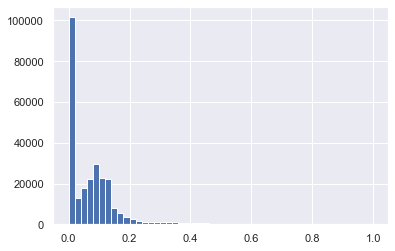

In [32]:
# Histogram with 50 bins
plt.hist(loan_data_defaults['recovery_rate'], bins = 50)
plt.show()

As seen above more than half of the values have a recovery_rate of 0.

So we can break this into 2 models.

1. Logistic regression model to predict if recovery_rate is 0 or not.

2. Linear regression model to predict the value of recover_rate if logistic regression predicts that recovery_rate is not 0.


In [33]:
# create another column having 0 if recovery_rate is 0 and 1 otherwise.
# This will be the target of the logistic regression model described above

loan_data_defaults['recovery_rate_0_1'] = np.where(loan_data_defaults['recovery_rate'] == 0, 0, 1)


C:\Users\ASUS\AppData\Local\Temp\ipykernel_9596\3492863380.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loan_data_defaults['recovery_rate_0_1'] = np.where(loan_data_defaults['recovery_rate'] == 0, 0, 1)


In [34]:
# sanity check
loan_data_defaults[loan_data_defaults['recovery_rate_0_1'] == 1].count()

loan_amnt                                                          177031
funded_amnt                                                        177031
funded_amnt_inv                                                    177031
int_rate                                                           177031
installment                                                        177031
grade                                                              177031
sub_grade                                                          177031
emp_title                                                          177031
home_ownership                                                     177031
annual_inc                                                         177031
verification_status                                                177031
issue_d                                                            177031
loan_status                                                        177031
pymnt_plan                            

In [35]:
loan_data_defaults[loan_data_defaults['recovery_rate_0_1'] == 0].count()

loan_amnt                                                          84819
funded_amnt                                                        84819
funded_amnt_inv                                                    84819
int_rate                                                           84819
installment                                                        84819
grade                                                              84819
sub_grade                                                          84819
emp_title                                                          84819
home_ownership                                                     84819
annual_inc                                                         84819
verification_status                                                84819
issue_d                                                            84819
loan_status                                                        84819
pymnt_plan                                         

#### Plotting CCF which is dependent variable for EAD model

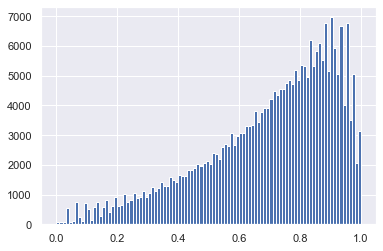

In [36]:
# Plot credit conversion factor into 50 bins

plt.hist(loan_data_defaults['CCF'], bins = 100)
plt.show()

# LGD Model



## Splitting into train and test sets

In [37]:
from sklearn.model_selection import train_test_split

## LGD Model stage 1 - Logistic regression to predict recovery_rate 0 or 1.



In [38]:
# LGD model stage 1 datasets: recovery rate 0 or greater than 0.

lgd_inputs_stage_1_train, lgd_inputs_stage_1_test, lgd_targets_stage_1_train, lgd_targets_stage_1_test = train_test_split(loan_data_defaults.drop(['recovery_rate','recovery_rate_0_1', 'CCF'], axis = 1), loan_data_defaults['recovery_rate_0_1'], test_size = 0.2, random_state = 42)


In [39]:
# Sanity check

print (lgd_inputs_stage_1_train.shape)
print (lgd_inputs_stage_1_test.shape)
print (lgd_targets_stage_1_train.shape)
print (lgd_targets_stage_1_test.shape)

(209480, 244)
(52370, 244)
(209480,)
(52370,)


## Keep only required features for stage 1 model

In [40]:
lgd_inputs_stage_1_train['issue_d_date'].head(5)

2064454   2014-03-01
1806609   2013-02-01
1672770   2017-04-01
1868429   2014-12-01
1946666   2014-09-01
Name: issue_d_date, dtype: datetime64[ns]

In [41]:
# List containing all independent variables
features_all = [
       'delinq_2yrs', 'inq_last_6mths', 'mths_since_last_delinq',
       'mths_since_last_record', 'open_acc', 'pub_rec', 'last_pymnt_d',
       'last_pymnt_amnt', 'next_pymnt_d',
       'mths_since_last_major_derog',
       'credit_history',
       'emp_length_int', 'term_int',  'mths_since_issue_d',
       'grade:A', 'grade:B', 'grade:C', 'grade:D', 'grade:E', 'grade:F',
       'grade:G', 'sub_grade:A1', 'sub_grade:A2', 'sub_grade:A3',
       'sub_grade:A4', 'sub_grade:A5', 'sub_grade:B1', 'sub_grade:B2',
       'sub_grade:B3', 'sub_grade:B4', 'sub_grade:B5', 'sub_grade:C1',
       'sub_grade:C2', 'sub_grade:C3', 'sub_grade:C4', 'sub_grade:C5',
       'sub_grade:D1', 'sub_grade:D2', 'sub_grade:D3', 'sub_grade:D4',
       'sub_grade:D5', 'sub_grade:E1', 'sub_grade:E2', 'sub_grade:E3',
       'sub_grade:E4', 'sub_grade:E5', 'sub_grade:F1', 'sub_grade:F2',
       'sub_grade:F3', 'sub_grade:F4', 'sub_grade:F5', 'sub_grade:G1',
       'sub_grade:G2', 'sub_grade:G3', 'sub_grade:G4',
       'home_ownership:ANY', 'home_ownership:MORTGAGE',
       'home_ownership:NONE', 'home_ownership:OTHER',
       'home_ownership:OWN', 'home_ownership:RENT',
       'verification_status:Not Verified',
       'verification_status:Source Verified',
       'verification_status:Verified',
       'purpose:car', 'purpose:credit_card', 'purpose:debt_consolidation',
       'purpose:educational', 'purpose:home_improvement', 'purpose:house',
       'purpose:major_purchase', 'purpose:medical', 'purpose:moving',
       'purpose:other', 'purpose:renewable_energy',
       'purpose:small_business', 'purpose:vacation', 'purpose:wedding',
       'pymnt_plan:n', 'initial_list_status:f', 'initial_list_status:w',
       'application_type:Individual', 'application_type:Joint App',
       'hardship_flag:N', 'debt_settlement_flag:N',
       'debt_settlement_flag:Y', 'disbursement_method:Cash',
       'disbursement_method:DirectPay']

In [42]:
# List contianing reference variables
features_reference_cat = ['grade:G', 'sub_grade:G4',
'home_ownership:RENT',
'verification_status:Verified',
'purpose:credit_card',
'initial_list_status:f', 'pymnt_plan:n', 'initial_list_status:f', 'application_type:Individual', 'hardship_flag:N', 'debt_settlement_flag:Y', 'disbursement_method:Cash']

In [43]:
# Remove other variables

lgd_inputs_stage_1_train = lgd_inputs_stage_1_train[features_all]

In [44]:
# Remove reference variables like we did before

lgd_inputs_stage_1_train = lgd_inputs_stage_1_train.drop(features_reference_cat, axis = 1)




In [45]:
# Sanity check
# Check for missing values. 
lgd_inputs_stage_1_train.isnull().sum()

delinq_2yrs                            0
inq_last_6mths                         0
mths_since_last_delinq                 0
mths_since_last_record                 0
open_acc                               0
pub_rec                                0
last_pymnt_d                           0
last_pymnt_amnt                        0
next_pymnt_d                           0
mths_since_last_major_derog            0
credit_history                         0
emp_length_int                         0
term_int                               0
mths_since_issue_d                     0
grade:A                                0
grade:B                                0
grade:C                                0
grade:D                                0
grade:E                                0
grade:F                                0
sub_grade:A1                           0
sub_grade:A2                           0
sub_grade:A3                           0
sub_grade:A4                           0
sub_grade:A5    

# Model training



In [46]:
from sklearn import linear_model
import scipy.stats as stat

class LogisticRegression_with_p_values:
    
    def __init__(self,*args,**kwargs):#,**kwargs):
        self.model = linear_model.LogisticRegression(*args,**kwargs)#,**args)

    def fit(self,X,y):
        self.model.fit(X,y)
        
        #### Get p-values for the fitted model ####
        denom = (2.0 * (1.0 + np.cosh(self.model.decision_function(X))))
        denom = np.tile(denom,(X.shape[1],1)).T
        F_ij = np.dot((X / denom).T,X) ## Fisher Information Matrix
        Cramer_Rao = np.linalg.inv(F_ij) ## Inverse Information Matrix
        sigma_estimates = np.sqrt(np.diagonal(Cramer_Rao))
        z_scores = self.model.coef_[0] / sigma_estimates # z-score for eaach model coefficient
        p_values = [stat.norm.sf(abs(x)) * 2 for x in z_scores] ### two tailed test for p-values
        
        self.coef_ = self.model.coef_
        self.intercept_ = self.model.intercept_
        #self.z_scores = z_scores
        self.p_values = p_values
        #self.sigma_estimates = sigma_estimates
        #self.F_ij = F_ij

In [63]:
# Object of extended LogisticRegression_with_p_values class
reg_lgd_st_1 = LogisticRegression_with_p_values()

# Fit data into model
reg_lgd_st_1.fit(lgd_inputs_stage_1_train, lgd_targets_stage_1_train)

C:\Users\ASUS\AppData\Roaming\Python\Python39\site-packages\sklearn\linear_model\_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_9596\3031655097.py:17: RuntimeWarning: invalid value encountered in sqrt
  sigma_estimates = np.sqrt(np.diagonal(Cramer_Rao))


In [68]:
# get all feature names into a list
feature_name = lgd_inputs_stage_1_train.columns.values


In [64]:
# Creates a dataframe with a column titled 'Feature name' and row values contained in the 'feature_name' variable.
summary_table = pd.DataFrame(columns = ['Feature name'], data = feature_name)
# Creates a new column in the dataframe, called 'Coefficients',
# with row values the transposed coefficients from the 'LogisticRegression' object.
summary_table['Coefficients'] = np.transpose(reg_lgd_st_1.coef_)

summary_table

,Feature name,Coefficients
0,delinq_2yrs,0.100066
1,inq_last_6mths,0.072012
2,mths_since_last_delinq,0.004704
3,mths_since_last_record,-0.000871
4,open_acc,-0.019693
5,pub_rec,0.037387
6,last_pymnt_d,-0.124185
7,last_pymnt_amnt,-0.000034
8,next_pymnt_d,0.126410
9,mths_since_last_major_derog,-0.001266


In [65]:
# Increases the index of every row of the dataframe with 1.
summary_table.index = summary_table.index + 1
# Put the value of intercept  in the row having index = 0
summary_table.loc[0] = ['Intercept', reg_lgd_st_1.intercept_[0]]
# sort by index
summary_table = summary_table.sort_index()
summary_table

,Feature name,Coefficients
0,Intercept,-0.125576
1,delinq_2yrs,0.100066
2,inq_last_6mths,0.072012
3,mths_since_last_delinq,0.004704
4,mths_since_last_record,-0.000871
5,open_acc,-0.019693
6,pub_rec,0.037387
7,last_pymnt_d,-0.124185
8,last_pymnt_amnt,-0.000034
9,next_pymnt_d,0.126410


In [69]:
# get p_values from model 

p_values = reg_lgd_st_1.p_values

# add nan corresponding to intercept in this array

p_values = np.append(np.nan,np.array(p_values))

# put p_values into summary table

summary_table['p_values'] = p_values

summary_table


,Feature name,Coefficients,p_values
0,Intercept,-0.125576,NaN
1,delinq_2yrs,0.100066,2.234736e-68
2,inq_last_6mths,0.072012,9.117577e-44
3,mths_since_last_delinq,0.004704,2.284540e-70
4,mths_since_last_record,-0.000871,6.227787e-05
5,open_acc,-0.019693,2.242987e-111
6,pub_rec,0.037387,4.297902e-04
7,last_pymnt_d,-0.124185,1.672516e-02
8,last_pymnt_amnt,-0.000034,1.162627e-04
9,next_pymnt_d,0.126410,1.612207e-01


# Testing the LGD model



In [72]:
# predict probability instead of just the class

y_hat_test_proba_lgd_stage_1 = reg_lgd_st_1.model.predict_proba(lgd_inputs_stage_1_test)


In [74]:
# This is a 2D array where each row sums to 1
# The first value in each row = Prob(recovery_rate = 0)
# The second value in each row = Prob (recovery_rate > 0)
y_hat_test_proba_lgd_stage_1

array([[0.38647803, 0.61352197],
       [0.42825754, 0.57174246],
       [0.30544714, 0.69455286],
       ...,
       [0.22305912, 0.77694088],
       [0.37450732, 0.62549268],
       [0.39166329, 0.60833671]])

In [75]:
# Put Prob (recovery_rate > 0) into a seperate variable

y_hat_test_proba_lgd_stage_1 = y_hat_test_proba_lgd_stage_1[: ][: , 1]

In [76]:
y_hat_test_proba_lgd_stage_1

array([0.61352197, 0.57174246, 0.69455286, ..., 0.77694088, 0.62549268,
       0.60833671])

In [77]:
# create a new dataframe with all test samples
lgd_targets_stage_1_test_temp = lgd_targets_stage_1_test
# Reset index
lgd_targets_stage_1_test_temp.reset_index(drop = True, inplace = True)

In [78]:
# concate 2 data frames
df_actual_predicted_probs = pd.concat([lgd_targets_stage_1_test_temp, pd.DataFrame(y_hat_test_proba_lgd_stage_1)], axis = 1)


In [79]:
# Name columns of new dataframe
df_actual_predicted_probs.columns = ['lgd_targets_stage_1_test', 'y_hat_test_proba_lgd_stage_1']

In [80]:
# Sets index to be same as index of lgd_inputs_stage_1_test

df_actual_predicted_probs.index = lgd_inputs_stage_1_test.index


In [81]:
df_actual_predicted_probs.head()

,lgd_targets_stage_1_test,y_hat_test_proba_lgd_stage_1
680227,0,0.613522
1058909,1,0.571742
1051855,0,0.694553
1026699,1,0.744580
1928768,1,0.821998


In [82]:
# sanity check
df_actual_predicted_probs.shape

(52370, 2)

# Check performace of model


In [83]:
# Set threshold
tr = 0.5
# Compute predictions
df_actual_predicted_probs['y_hat_test_lgd_stage_1'] = np.where(df_actual_predicted_probs['y_hat_test_proba_lgd_stage_1'] > tr, 1, 0)

In [84]:
# Creates a cross-table where the actual values are displayed by rows and the predicted values by columns.
# This table is known as a Confusion Matrix. You can also use the confusion_matrix function from sklearn

pd.crosstab(df_actual_predicted_probs['lgd_targets_stage_1_test'], df_actual_predicted_probs['y_hat_test_lgd_stage_1'], rownames = ['Actual'], colnames = ['Predicted'])


Predicted,0,1
Actual,,
0,3145,13829
1,2193,33203


In [85]:
# Divide each value of the table by the total number of observations,
# thus getting percentages, or, rates.
pd.crosstab(df_actual_predicted_probs['lgd_targets_stage_1_test'], df_actual_predicted_probs['y_hat_test_lgd_stage_1'], rownames = ['Actual'], colnames = ['Predicted']) / df_actual_predicted_probs.shape[0]


Predicted,0,1
Actual,,
0,0.060053,0.264063
1,0.041875,0.634008


In [86]:
# Compute accuracy
(pd.crosstab(df_actual_predicted_probs['lgd_targets_stage_1_test'], df_actual_predicted_probs['y_hat_test_lgd_stage_1'], rownames = ['Actual'], colnames = ['Predicted']) / df_actual_predicted_probs.shape[0]).iloc[0, 0] + (pd.crosstab(df_actual_predicted_probs['lgd_targets_stage_1_test'], df_actual_predicted_probs['y_hat_test_lgd_stage_1'], rownames = ['Actual'], colnames = ['Predicted']) / df_actual_predicted_probs.shape[0]).iloc[1, 1]


0.6940614855833492

In [87]:
from sklearn.metrics import roc_curve, roc_auc_score

In [88]:
# Returns the Receiver Operating Characteristic (ROC) Curve from a set of actual values and their predicted probabilities.
# As a result, we get three arrays: the false positive rates, the true positive rates, and the thresholds.
# we store each of the three arrays in a separate variable.
fpr, tpr, thresholds = roc_curve(df_actual_predicted_probs['lgd_targets_stage_1_test'], df_actual_predicted_probs['y_hat_test_proba_lgd_stage_1'])


Text(0.5, 1.0, 'ROC curve')

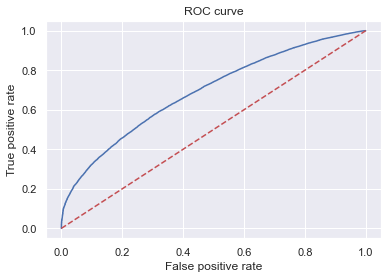

In [89]:
# Plot the ROC curve
plt.plot(fpr, tpr)
plt.plot(fpr, fpr, linestyle = '--', color = 'r')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve')

In [90]:
# Compute AUCROC

AUROC = roc_auc_score(df_actual_predicted_probs['lgd_targets_stage_1_test'], df_actual_predicted_probs['y_hat_test_proba_lgd_stage_1'])

AUROC

0.6911652490045367

In [91]:
# Find best threshold
optimal_rate = tpr - fpr 
optimal_idx = np.argmax(optimal_rate)
best_thresh = thresholds[optimal_idx]
print('Best Threshold=%f' % (best_thresh))

Best Threshold=0.695290


In [ ]:
#Check the confusion matrix with the best threshold

tr=0.695290

# if predicted prob > 0.695290 then predict 1 else predict 0
df_actual_predicted_probs['y_hat_test_lgd_stage_1'] = np.where(df_actual_predicted_probs['y_hat_test_proba_lgd_stage_1'] > tr, 1, 0)
pd.crosstab(df_actual_predicted_probs['lgd_targets_stage_1_test'], df_actual_predicted_probs['y_hat_test_lgd_stage_1'], rownames = ['Actual'], colnames = ['Predicted'])



Predicted,0,1
Actual,,
0,11786,5188
1,15005,20391


In [93]:
# Compute accuract
(pd.crosstab(df_actual_predicted_probs['lgd_targets_stage_1_test'], df_actual_predicted_probs['y_hat_test_lgd_stage_1'], rownames = ['Actual'], colnames = ['Predicted']) / df_actual_predicted_probs.shape[0]).iloc[0, 0] + (pd.crosstab(df_actual_predicted_probs['lgd_targets_stage_1_test'], df_actual_predicted_probs['y_hat_test_lgd_stage_1'], rownames = ['Actual'], colnames = ['Predicted']) / df_actual_predicted_probs.shape[0]).iloc[1, 1]


0.6144166507542486

In [94]:
# Manual check
print ("accuracy = ", (11786+20391)/df_actual_predicted_probs.shape[0])

accuracy =  0.6144166507542486


## Save the stage 1 model 

So we can load it into any notebook we use to build stage 2 model



In [ ]:
import pickle


In [132]:
# Save stage 1 model 

pickle.dump(reg_lgd_st_1, open('lgd_model_stage_1.sav', 'wb'))

# Stage 2 model - Linear regression

We will use this model on samples where stage 1 model predicts recovery_rate to be greater than 0.


In [133]:
# Keep on samples where recovery_rate = 1

lgd_stage_2_data = loan_data_defaults[loan_data_defaults['recovery_rate_0_1'] == 1]



In [134]:
# 80-20 train test split with random_state = 42 

lgd_inputs_stage_2_train, lgd_inputs_stage_2_test, lgd_targets_stage_2_train, lgd_targets_stage_2_test = train_test_split(lgd_stage_2_data.drop(['recovery_rate','recovery_rate_0_1', 'CCF'], axis = 1), lgd_stage_2_data['recovery_rate'], test_size = 0.2, random_state = 42)


In [135]:
# sanity check

print (lgd_inputs_stage_2_train.shape)

print (lgd_inputs_stage_2_test.shape)

print (lgd_targets_stage_2_train.shape)

print (lgd_targets_stage_2_test.shape)

(141624, 244)
(35407, 244)
(141624,)
(35407,)


In [136]:
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score

In [137]:
# Keep only the feature we are going to use to train model

lgd_inputs_stage_2_train = lgd_inputs_stage_2_train[features_all]

# Remove dummy variable

lgd_inputs_stage_2_train = lgd_inputs_stage_2_train.drop(features_reference_cat, axis = 1)


In [138]:
# Create linear regression model object
reg_lgd_st_2 = linear_model.LinearRegression()

# fit data into the model
reg_lgd_st_2.fit(lgd_inputs_stage_2_train, lgd_targets_stage_2_train)


LinearRegression()

In [139]:
# Stores the names of the columns of a dataframe in a variable.

feature_name = lgd_inputs_stage_2_train.columns.values

In [140]:
# Creates a dataframe with a column titled 'Feature name' and row values contained in the 'feature_name' variable.
summary_table = pd.DataFrame(columns = ['Feature name'], data = feature_name)

# Creates a new column in the dataframe, called 'Coefficients',
# with row values the transposed coefficients from the 'LogisticRegression' object.
summary_table['Coefficients'] = np.transpose(reg_lgd_st_2.coef_)



In [141]:
# Increases the index of every row of the dataframe with 1.
summary_table.index = summary_table.index + 1

# Assigns values of intercept to the row with index 0 of the dataframe.
summary_table.loc[0] = ['Intercept', reg_lgd_st_2.intercept_]

# Sort dataframe by index

summary_table = summary_table.sort_index()


summary_table

,Feature name,Coefficients
0,Intercept,0.270287
1,delinq_2yrs,0.000091
2,inq_last_6mths,0.000794
3,mths_since_last_delinq,-0.000011
4,mths_since_last_record,-0.000012
5,open_acc,-0.000002
6,pub_rec,-0.001356
7,last_pymnt_d,-0.051359
8,last_pymnt_amnt,-0.000003
9,next_pymnt_d,0.005690


# Stage 2 model evaluation

In [142]:
#  Keep only the variables we need for the model.

lgd_inputs_stage_2_test = lgd_inputs_stage_2_test[features_all]


In [143]:
# Remove the dummy variable reference categories.

lgd_inputs_stage_2_test = lgd_inputs_stage_2_test.drop(features_reference_cat, axis = 1)


In [144]:
# Use trained model to predict

y_hat_test_lgd_stage_2 = reg_lgd_st_2.predict(lgd_inputs_stage_2_test)


In [145]:
# Sanity check

y_hat_test_lgd_stage_2.shape

(35407,)

In [146]:
# Create copy of dataframe containing test targets and reset its index
lgd_targets_stage_2_test_temp = lgd_targets_stage_2_test
lgd_targets_stage_2_test_temp.reset_index(drop=True, inplace=True)
lgd_targets_stage_2_test_temp.head()

0    0.041620
1    0.108052
2    0.098030
3    0.090197
4    0.109808
Name: recovery_rate, dtype: float64

In [147]:
# Concatenate the 2 dataframes
df = pd.concat([lgd_targets_stage_2_test_temp, pd.DataFrame(y_hat_test_lgd_stage_2)], axis = 1)
# compute correlation

df.corr()

,recovery_rate,0
recovery_rate,1.000000,0.377325
0,0.377325,1.000000


In [158]:
# Check residuals
# sns.histplot(lgd_targets_stage_2_test - y_hat_test_lgd_stage_2, kde=True)


In [151]:
# Save stage 2 model

pickle.dump(reg_lgd_st_2, open('lgd_model_stage_2.sav', 'wb'))

# Combining stage 1 and stage 2 to create final LGD model

In [152]:
# predict on all test samples using stage 2 model

y_hat_test_lgd_stage_2_all = reg_lgd_st_2.predict(lgd_inputs_stage_1_test)

In [153]:
# check
y_hat_test_lgd_stage_2_all.shape

(52370,)

We use stage 2 prediction for samples for which stage 1 predicts 1 i.e recovery_rate > 1

If stage 1 predicts 0 i.e recovery_rate = 0 then we can ignore the prediction of stage 2 model



In [154]:
# multiply predictions of stage 1 and stage 2 element
# when stage 1 predicts 0 the final output will 0 * (stage 2 prediction) = 0


y_hat_test_lgd = y_hat_test_lgd_stage_1 * y_hat_test_lgd_stage_2_all


In [155]:
# check
pd.DataFrame(y_hat_test_lgd).describe()

,0
count,52370.000000
mean,0.095978
std,0.045746
min,-0.023215
25%,0.081308
50%,0.096062
75%,0.110797
max,0.495391


In [156]:
# The min value is less than 0 so replace it with 0
y_hat_test_lgd = np.where(y_hat_test_lgd < 0, 0, y_hat_test_lgd)


# EAD Model



In [159]:
# Data for EAD model. 
# Drop 'good_bad', 'recovery_rate','recovery_rate_0_1', 'CCF' 
# 'CCF' is the target

ead_inputs_train, ead_inputs_test, ead_targets_train, ead_targets_test = train_test_split(loan_data_defaults.drop(['recovery_rate','recovery_rate_0_1', 'CCF'], axis = 1), loan_data_defaults['CCF'], test_size = 0.2, random_state = 42)


In [160]:
#check

ead_inputs_train.columns.values

array(['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'int_rate',
       'installment', 'grade', 'sub_grade', 'emp_title', 'home_ownership',
       'annual_inc', 'verification_status', 'issue_d', 'loan_status',
       'pymnt_plan', 'purpose', 'title', 'addr_state', 'dti',
       'delinq_2yrs', 'inq_last_6mths', 'mths_since_last_delinq',
       'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal',
       'revol_util', 'total_acc', 'initial_list_status', 'out_prncp',
       'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv',
       'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee',
       'recoveries', 'collection_recovery_fee', 'last_pymnt_d',
       'last_pymnt_amnt', 'next_pymnt_d', 'collections_12_mths_ex_med',
       'mths_since_last_major_derog', 'policy_code', 'application_type',
       'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m',
       'open_act_il', 'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il',
       'total_bal_il', 'il_util', 'open_rv_12

In [161]:
# Filter out the variables that wont be used by the model

ead_inputs_train = ead_inputs_train[features_all]

In [162]:
# Remove the reference category variables
ead_inputs_train = ead_inputs_train.drop(features_reference_cat, axis = 1)


In [163]:
# Fit mode

reg_ead = linear_model.LinearRegression()

reg_ead.fit(ead_inputs_train, ead_targets_train)

LinearRegression()

In [164]:
# get feature names into a list
feature_name = ead_inputs_train.columns.values

In [165]:
# Build summary table for EAD model. Code is same as before the code used for lgd model

summary_table = pd.DataFrame(columns = ['Feature name'], data = feature_name)

summary_table['Coefficients'] = np.transpose(reg_ead.coef_)




In [166]:
summary_table

,Feature name,Coefficients
0,delinq_2yrs,-0.003078
1,inq_last_6mths,0.007805
2,mths_since_last_delinq,-0.000078
3,mths_since_last_record,-0.000085
4,open_acc,-0.000578
5,pub_rec,-0.007782
6,last_pymnt_d,-0.241427
7,last_pymnt_amnt,-0.000024
8,next_pymnt_d,0.174673
9,mths_since_last_major_derog,-0.000270


In [167]:
# Add intercept and reset indexes 
summary_table.index = summary_table.index + 1

summary_table.loc[0] = ['Intercept', reg_ead.intercept_]

summary_table = summary_table.sort_index()


In [168]:
# Check
summary_table

,Feature name,Coefficients
0,Intercept,1.207296
1,delinq_2yrs,-0.003078
2,inq_last_6mths,0.007805
3,mths_since_last_delinq,-0.000078
4,mths_since_last_record,-0.000085
5,open_acc,-0.000578
6,pub_rec,-0.007782
7,last_pymnt_d,-0.241427
8,last_pymnt_amnt,-0.000024
9,next_pymnt_d,0.174673


## Model testing


In [169]:
# remove features not used to train the model
ead_inputs_test = ead_inputs_test[features_all]

In [170]:
# check
features_reference_cat

['grade:G',
 'sub_grade:G4',
 'home_ownership:RENT',
 'verification_status:Verified',
 'purpose:credit_card',
 'initial_list_status:f',
 'pymnt_plan:n',
 'initial_list_status:f',
 'application_type:Individual',
 'hardship_flag:N',
 'debt_settlement_flag:Y',
 'disbursement_method:Cash']

In [171]:
#check
ead_inputs_test.columns

Index(['delinq_2yrs', 'inq_last_6mths', 'mths_since_last_delinq',
       'mths_since_last_record', 'open_acc', 'pub_rec', 'last_pymnt_d',
       'last_pymnt_amnt', 'next_pymnt_d', 'mths_since_last_major_derog',
       'credit_history', 'emp_length_int', 'term_int', 'mths_since_issue_d',
       'grade:A', 'grade:B', 'grade:C', 'grade:D', 'grade:E', 'grade:F',
       'grade:G', 'sub_grade:A1', 'sub_grade:A2', 'sub_grade:A3',
       'sub_grade:A4', 'sub_grade:A5', 'sub_grade:B1', 'sub_grade:B2',
       'sub_grade:B3', 'sub_grade:B4', 'sub_grade:B5', 'sub_grade:C1',
       'sub_grade:C2', 'sub_grade:C3', 'sub_grade:C4', 'sub_grade:C5',
       'sub_grade:D1', 'sub_grade:D2', 'sub_grade:D3', 'sub_grade:D4',
       'sub_grade:D5', 'sub_grade:E1', 'sub_grade:E2', 'sub_grade:E3',
       'sub_grade:E4', 'sub_grade:E5', 'sub_grade:F1', 'sub_grade:F2',
       'sub_grade:F3', 'sub_grade:F4', 'sub_grade:F5', 'sub_grade:G1',
       'sub_grade:G2', 'sub_grade:G3', 'sub_grade:G4', 'home_ownership:ANY',

In [172]:
# remove categorical features for discrete features
ead_inputs_test = ead_inputs_test.drop(features_reference_cat, axis = 1)


In [173]:
# check
ead_inputs_test.columns.values

array(['delinq_2yrs', 'inq_last_6mths', 'mths_since_last_delinq',
       'mths_since_last_record', 'open_acc', 'pub_rec', 'last_pymnt_d',
       'last_pymnt_amnt', 'next_pymnt_d', 'mths_since_last_major_derog',
       'credit_history', 'emp_length_int', 'term_int',
       'mths_since_issue_d', 'grade:A', 'grade:B', 'grade:C', 'grade:D',
       'grade:E', 'grade:F', 'sub_grade:A1', 'sub_grade:A2',
       'sub_grade:A3', 'sub_grade:A4', 'sub_grade:A5', 'sub_grade:B1',
       'sub_grade:B2', 'sub_grade:B3', 'sub_grade:B4', 'sub_grade:B5',
       'sub_grade:C1', 'sub_grade:C2', 'sub_grade:C3', 'sub_grade:C4',
       'sub_grade:C5', 'sub_grade:D1', 'sub_grade:D2', 'sub_grade:D3',
       'sub_grade:D4', 'sub_grade:D5', 'sub_grade:E1', 'sub_grade:E2',
       'sub_grade:E3', 'sub_grade:E4', 'sub_grade:E5', 'sub_grade:F1',
       'sub_grade:F2', 'sub_grade:F3', 'sub_grade:F4', 'sub_grade:F5',
       'sub_grade:G1', 'sub_grade:G2', 'sub_grade:G3',
       'home_ownership:ANY', 'home_ownership:MOR

In [174]:
# Predict
y_hat_test_ead = reg_ead.predict(ead_inputs_test)

In [175]:
# Create a new variable containing test samples

ead_targets_test_temp = ead_targets_test

# reset index of new dataframe

ead_targets_test_temp = ead_targets_test_temp.reset_index(drop = True)

In [176]:
# Compute coorelation between the actual and predicted values

pd.concat([ead_targets_test_temp, pd.DataFrame(y_hat_test_ead)], axis = 1).corr()


,CCF,0
CCF,1.000000,0.516807
0,0.516807,1.000000


In [178]:
pd.DataFrame(y_hat_test_ead).describe()


,0
count,52370.000000
mean,0.698692
std,0.112153
min,-0.178530
25%,0.622555
50%,0.696438
75%,0.774808
max,1.253101



Note: CCF lies in between 0 and 1 but our linear regression model is not restricted.

In [179]:
# set predicted values > 1 to 1

y_hat_test_ead = np.where(y_hat_test_ead > 1, 1, y_hat_test_ead)

In [180]:
pd.DataFrame(y_hat_test_ead).describe()

,0
count,52370.000000
mean,0.698270
std,0.110743
min,-0.178530
25%,0.622555
50%,0.696438
75%,0.774808
max,1.000000


In [181]:
# Save the EAD model

pickle.dump(reg_ead, open('ead_model_.sav', 'wb'))